# Embeddings and Semantic Representation

How do we turn words into numbers that capture **meaning**?

In this notebook, we go from the simplest representation to the most powerful:

1. **One-hot encoding** — the baseline (no meaning)
2. **Bag of Words vectors** — frequency counts (still no real meaning)
3. **GloVe word embeddings** — pretrained vectors that capture word relationships
4. **Sentence embeddings** — encode full sentences into a vector space

Along the way, we will **visualize** how words cluster together in vector space.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

## 0. Cosine Similarity — the ruler of the vector space

Before we look at embeddings, we need one key tool: **cosine similarity**.

It is the most common way to measure how similar two vectors are, and it shows up in every part of NLP — comparing words, sentences, documents, search results, and more.


### What does it measure?

Cosine similarity measures the **angle** between two vectors, not their length.

Imagine two arrows starting from the origin:

- If they point in the **same direction** → angle = 0° → similarity = **1.0** (identical meaning)
- If they point **perpendicular** → angle = 90° → similarity = **0.0** (unrelated)
- If they point in **opposite directions** → angle = 180° → similarity = **−1.0** (opposite meaning)

We care about direction, not size — a long vector and a short vector pointing the same way are considered identical.

### The formula

For two vectors **A** and **B**:

$$
\text{cosine\_similarity}(A, B) = \frac{A \cdot B}{\|A\| \cdot \|B\|}
$$

Where:
- $A \cdot B$ = **dot product**: multiply element-by-element and sum
- $\|A\|$ = **norm** (length) of vector A = $\sqrt{a_1^2 + a_2^2 + \ldots}$
- Dividing by the norms removes the effect of vector length

**Result** is always in the range **[−1, +1]** for real-valued vectors.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Let's compute cosine similarity manually step by step

# Two simple 2D vectors
A = np.array([3.0, 1.0])
B = np.array([2.0, 2.0])

# Step 1: dot product
dot = np.dot(A, B)

# Step 2: norms
norm_A = np.linalg.norm(A)
norm_B = np.linalg.norm(B)

# Step 3: cosine similarity
cos_sim = dot / (norm_A * norm_B)

print(f'A             = {A}')
print(f'B             = {B}')
print(f'Dot product   = {dot}')
print(f'Norm of A     = {norm_A:.4f}')
print(f'Norm of B     = {norm_B:.4f}')
print(f'Cosine sim    = {cos_sim:.4f}')

A             = [3. 1.]
B             = [2. 2.]
Dot product   = 8.0
Norm of A     = 3.1623
Norm of B     = 2.8284
Cosine sim    = 0.8944


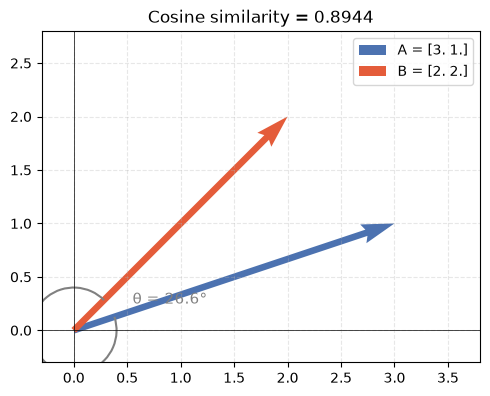

In [ ]:
# Visualize the two vectors and the angle between them

fig, ax = plt.subplots(figsize=(5, 5))

origin = [0, 0]
ax.quiver(*origin, *A, color='#4C72B0', angles='xy', scale_units='xy', scale=1,
          width=0.015, label=f'A = {A}')
ax.quiver(*origin, *B, color='#E45C3A', angles='xy', scale_units='xy', scale=1,
          width=0.015, label=f'B = {B}')

# Draw the angle arc
angle_deg = np.degrees(np.arccos(cos_sim))
arc = plt.matplotlib.patches.Arc((0, 0), 0.8, 0.8,
                                   angle=0,
                                   theta1=np.degrees(np.arctan2(B[1], B[0])),
                                   theta2=np.degrees(np.arctan2(A[1], A[0])),
                                   color='gray', lw=1.5)
ax.add_patch(arc)
ax.text(0.55, 0.25, f'θ = {angle_deg:.1f}°', fontsize=11, color='gray')

ax.set_xlim(-0.3, 3.8)
ax.set_ylim(-0.3, 2.8)
ax.set_aspect('equal')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.legend(fontsize=10)
ax.set_title(f'Cosine similarity = {cos_sim:.4f}', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Three cases to build intuition

Let's try three pairs of vectors that demonstrate the full range:

In [ ]:
cases = [
    ('Same direction   (sim ≈ 1.0)',  np.array([1.0, 2.0]), np.array([2.0, 4.0])),
    ('Perpendicular    (sim = 0.0)',   np.array([1.0, 0.0]), np.array([0.0, 1.0])),
    ('Opposite direction (sim ≈ -1.0)', np.array([1.0, 2.0]), np.array([-1.0, -2.0])),
]

for label, u, v in cases:
    sim = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    print(f'{label:<38}  A={u}  B={v}  → cosine = {sim:+.4f}')

Same direction   (sim ≈ 1.0)            A=[1. 2.]  B=[2. 4.]  → cosine = +1.0000
Perpendicular    (sim = 0.0)            A=[1. 0.]  B=[0. 1.]  → cosine = +0.0000
Opposite direction (sim ≈ -1.0)         A=[1. 2.]  B=[-1. -2.]  → cosine = -1.0000


### Why is this useful in NLP?

When we represent words or sentences as vectors:

- **High cosine similarity** → similar meaning (`cat` ≈ `dog`, `king` ≈ `queen`)
- **Low cosine similarity** → different meaning (`cat` vs `car`)

We use it to:
- Find the most relevant document for a search query
- Cluster similar texts
- Detect paraphrases
- Power recommendation systems

> We will use `sklearn.metrics.pairwise.cosine_similarity` throughout this notebook — it handles all the math automatically.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Quick demo: sklearn's version gives the same result
A = np.array([[3.0, 1.0]])   # note: sklearn expects 2D arrays
B = np.array([[2.0, 2.0]])

print('sklearn cosine_similarity:', cosine_similarity(A, B)[0][0].round(4))
# Expected: same as our manual calculation above

sklearn cosine_similarity: 0.8944


---

## 1. One-hot encoding

The simplest way to represent a word is a **one-hot vector**: a vector of all zeros except a single 1 at the position of that word in the vocabulary.

| Word | Vector |
| --- | --- |
| `cat` | `[1, 0, 0, 0]` |
| `dog` | `[0, 1, 0, 0]` |
| `car` | `[0, 0, 1, 0]` |
| `bus` | `[0, 0, 0, 1]` |

In [ ]:
vocab = ["cat", "dog", "car", "bus"]

def one_hot(word, vocab):
    vec = [0] * len(vocab)
    vec[vocab.index(word)] = 1
    return vec

for word in vocab:
    print(f"{word:<6} -> {one_hot(word, vocab)}")

cat    -> [1, 0, 0, 0]
dog    -> [0, 1, 0, 0]
car    -> [0, 0, 1, 0]
bus    -> [0, 0, 0, 1]


### The problem with one-hot vectors

Every pair of one-hot vectors has **cosine similarity = 0**.

The model cannot tell that `cat` and `dog` are more similar to each other than to `car`.

In [ ]:
cat_vec = np.array(one_hot("cat", vocab)).reshape(1, -1)
dog_vec = np.array(one_hot("dog", vocab)).reshape(1, -1)
car_vec = np.array(one_hot("car", vocab)).reshape(1, -1)

print("Similarity cat vs dog :", cosine_similarity(cat_vec, dog_vec)[0][0])  # 0.0
print("Similarity cat vs car :", cosine_similarity(cat_vec, car_vec)[0][0])  # 0.0

Similarity cat vs dog : 0.0
Similarity cat vs car : 0.0


Both similarities are `0.0`. One-hot vectors carry no information about meaning.

## 2. Bag of Words vectors

Bag of Words counts how often each vocabulary word appears in a text.

It is better than one-hot because shared words push two texts closer together.

But it still loses word order and does not understand synonyms.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

texts = [
    "I love cats and dogs",
    "My dog loves to play",
    "The car drives fast",
    "Fast cars win races",
]

cv = CountVectorizer()
X  = cv.fit_transform(texts).toarray()

import pandas as pd
pd.DataFrame(X, columns=cv.get_feature_names_out(), index=texts)

,and,car,cars,cats,dog,dogs,drives,fast,love,loves,my,play,races,the,to,win
I love cats and dogs,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
My dog loves to play,0,0,0,0,1,0,0,0,0,1,1,1,0,0,1,0
The car drives fast,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,0
Fast cars win races,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1


In [ ]:
# Are "I love cats and dogs" and "My dog loves to play" more similar than "The car drives fast"?
sim_12 = cosine_similarity(X[0:1], X[1:2])[0][0]
sim_13 = cosine_similarity(X[0:1], X[2:3])[0][0]

print(f"Sentence 1 vs 2 (both about pets): {sim_12:.8f}")
print(f"Sentence 1 vs 3 (pets vs cars)  : {sim_13:.8f}")

Sentence 1 vs 2 (both about pets): 0.00000000
Sentence 1 vs 3 (pets vs cars)  : 0.00000000


BoW can detect shared words, but if you use `dog` in one sentence and `puppy` in another, similarity will be low even though they mean the same thing.

> BoW understands **vocabulary overlap**, not **meaning**.

## 3. GloVe word embeddings

**GloVe** (Global Vectors for Word Representation) is a set of pretrained word vectors.

Each word is mapped to a dense vector (e.g., 50 or 300 numbers) trained on billions of words.

Words that appear in similar contexts get similar vectors.

```
pip install gensim
```

> The first run downloads the `glove-wiki-gigaword-50` model (~66 MB). Subsequent runs load it from cache.

In [ ]:
import gensim.downloader as api

# 50-dimensional GloVe vectors trained on Wikipedia
glove = api.load("glove-wiki-gigaword-50")
print(f"Vocabulary size: {len(glove.key_to_index):,}")
print(f"Vector size    : {glove.vector_size}")

Vocabulary size: 400,000
Vector size    : 50


In [ ]:
# Each word is now a 50-dimensional vector
print("Vector for 'king' (first 8 dims):", glove["king"][:8].round(3))

Vector for 'king' (first 8 dims): [ 0.505  0.686 -0.595 -0.023  0.6   -0.135 -0.088  0.474]


### Word similarity with GloVe

Words with similar meanings have vectors that point in similar directions.

In [ ]:
print("cat  vs dog  :", round(glove.similarity("cat",  "dog"),  3))  # high
print("cat  vs car  :", round(glove.similarity("cat",  "car"),  3))  # lower
print("king vs queen:", round(glove.similarity("king", "queen"), 3))  # high

cat  vs dog  : 0.922
cat  vs car  : 0.364
king vs queen: 0.784


### Word analogies

GloVe encodes relationships between words as directions in the vector space.

The famous analogy: **king − man + woman ≈ queen**

In [ ]:
# king - man + woman = ?
result = glove.most_similar(positive=["king", "woman"], negative=["man"], topn=3)
for word, score in result:
    print(f"  {word:<12} similarity: {score:.3f}")

  queen        similarity: 0.852
  throne       similarity: 0.766
  prince       similarity: 0.759


## 4. Visualizing the vector space — PCA plot

GloVe vectors have 50 dimensions. We use **PCA** to project them to 2D so we can visualize them.

Words from the same category should cluster together.

In [ ]:
# Words organized by semantic category
categories = {
    "Animals" : ["cat", "dog", "lion", "tiger", "elephant"],
    "Countries": ["egypt", "france", "germany", "japan", "brazil"],
    "Tech"    : ["computer", "software", "algorithm", "network", "python"],
    "Sports"  : ["football", "basketball", "tennis", "swimming", "running"],
}

words, labels, colors_list = [], [], []
palette = {"Animals": "#E45C3A", "Countries": "#4C72B0", "Tech": "#55A868", "Sports": "#DD8452"}

for category, word_list in categories.items():
    for w in word_list:
        if w in glove:
            words.append(w)
            labels.append(category)
            colors_list.append(palette[category])

vectors = np.array([glove[w] for w in words])

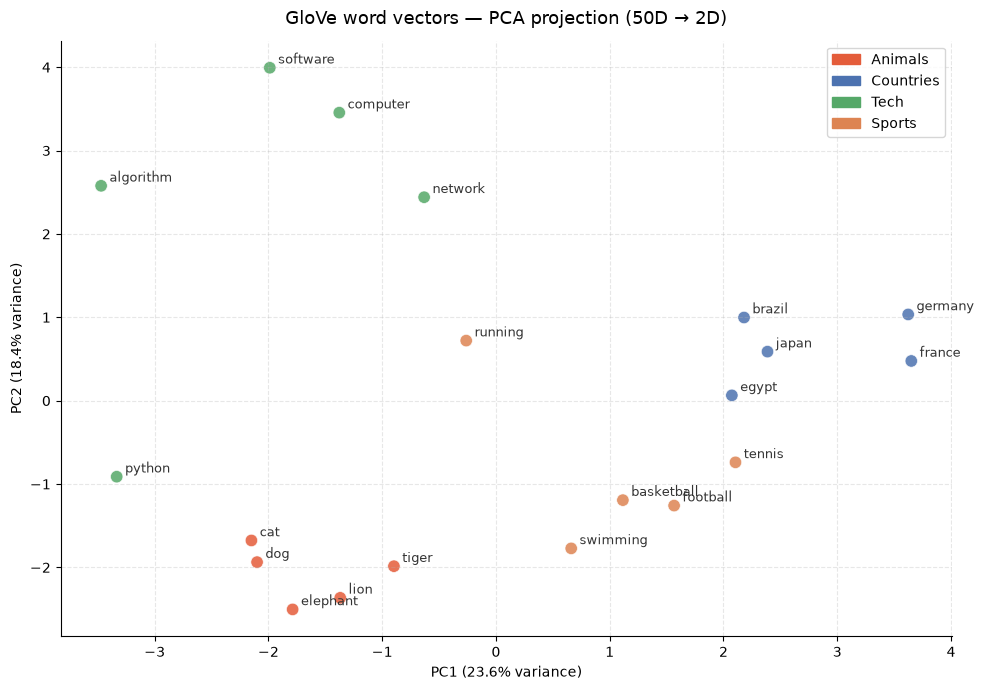

In [ ]:
# Project 50D -> 2D with PCA
pca  = PCA(n_components=2, random_state=42)
pts  = pca.fit_transform(vectors)

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(pts[:, 0], pts[:, 1], c=colors_list, s=80, alpha=0.85, edgecolors='white', linewidth=0.5)

for i, word in enumerate(words):
    ax.annotate(word, (pts[i, 0], pts[i, 1]),
                textcoords='offset points', xytext=(6, 3),
                fontsize=9, color='#333333')

legend_handles = [mpatches.Patch(color=c, label=cat) for cat, c in palette.items()]
ax.legend(handles=legend_handles, fontsize=10, loc='best')

ax.set_title('GloVe word vectors — PCA projection (50D → 2D)', fontsize=13, pad=12)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Words from the same category tend to cluster together in the 2D projection.

Countries cluster with countries, animals cluster with animals.
This is what it means for a vector space to encode **meaning**.

## 5. Sentence embeddings — `sentence-transformers`

Word embeddings represent individual words. For full sentences, we need **sentence embeddings**.

`sentence-transformers` encodes an entire sentence into a single fixed-size vector using a Transformer model.

```
pip install sentence-transformers
```

We use `all-MiniLM-L6-v2` — a small, fast model (80 MB) that produces 384-dimensional sentence vectors.

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded. Vector size:", model.get_sentence_embedding_dimension())

d:\ITI Summer Training\NLP Concepts\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3185.12it/s]


Model loaded. Vector size: 384


C:\Users\Asus\AppData\Local\Temp\ipykernel_27380\4257413830.py:4: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("Model loaded. Vector size:", model.get_sentence_embedding_dimension())


In [ ]:
sentences = [
    # --- pets / animals ---
    "My golden retriever loves to run and play fetch in the park every morning.",    # 0
    "I just adopted a rescue cat and she already feels at home on the couch.",       # 1

    # --- technology / AI ---
    "Deep learning models are trained on massive datasets to learn complex patterns.", # 2
    "Neural networks use layers of weighted connections to transform input data.",    # 3

    # --- sports ---
    "The basketball team won the championship after an intense overtime match.",      # 4
    "Soccer is the most popular sport in the world, played in every country.",       # 5

    # --- food ---
    "Italian pasta with homemade tomato sauce is my all-time favourite comfort food.",# 6
    "A good breakfast should include fresh fruit, whole grains, and some protein.",  # 7
]

embeddings = model.encode(sentences)
print(f"Shape: {embeddings.shape}  (8 sentences x 384 dimensions)")

Shape: (8, 384)  (8 sentences x 384 dimensions)


## 6. Cosine similarity heatmap

Let's compute the similarity between every pair of sentences and visualize it as a heatmap.

- A score close to **1.0** means the sentences are semantically very similar.
- A score close to **0.0** means they are unrelated.

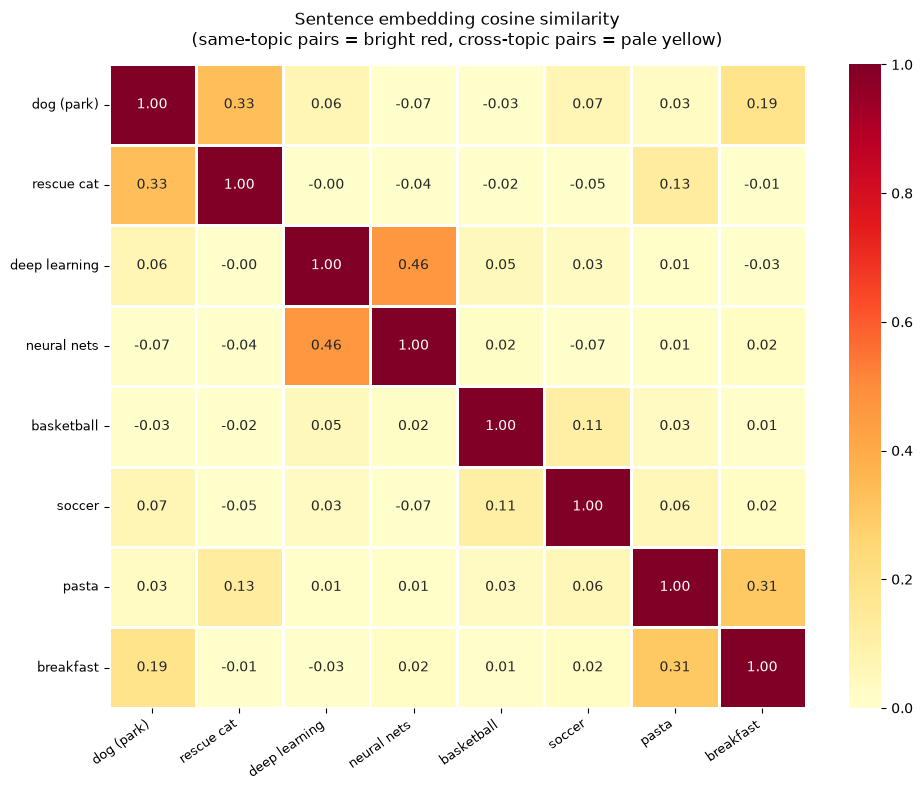


Same-topic pairs (should be HIGH):
--------------------------------------------------------------
  [pets    ]  dog (park)         vs rescue cat          ->  0.334
  [AI/tech ]  deep learning      vs neural nets         ->  0.465
  [sports  ]  basketball         vs soccer              ->  0.114
  [food    ]  pasta              vs breakfast           ->  0.308

Cross-topic pairs (should be LOW):
--------------------------------------------------------------
  [pets vs AI      ]  dog (park)         vs deep learning       ->  0.063
  [pets vs sports  ]  dog (park)         vs basketball          ->  -0.028
  [AI vs food      ]  deep learning      vs pasta               ->  0.010
  [sports vs food  ]  basketball         vs pasta               ->  0.034


In [ ]:
sim_matrix = cosine_similarity(embeddings)

# Short labels that fit on the axis
short_labels = [
    "dog (park)",
    "rescue cat",
    "deep learning",
    "neural nets",
    "basketball",
    "soccer",
    "pasta",
    "breakfast",
]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    sim_matrix, annot=True, fmt='.2f',
    xticklabels=short_labels, yticklabels=short_labels,
    cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.8, linecolor='white',
    annot_kws={'size': 10},
    ax=ax
)
ax.set_title(
    'Sentence embedding cosine similarity\n'
    '(same-topic pairs = bright red, cross-topic pairs = pale yellow)',
    fontsize=12, pad=14
)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# ── Print the scores so they are easy to read ─────────────────────────────
print("\nSame-topic pairs (should be HIGH):")
print("-" * 62)
same_topic = [(0, 1, 'pets'), (2, 3, 'AI/tech'), (4, 5, 'sports'), (6, 7, 'food')]
for i, j, topic in same_topic:
    s = sim_matrix[i, j]
    print(f"  [{topic:<8}]  {short_labels[i]:<18} vs {short_labels[j]:<18}  ->  {s:.3f}")

print("\nCross-topic pairs (should be LOW):")
print("-" * 62)
cross_topic = [
    (0, 2, 'pets vs AI'),
    (0, 4, 'pets vs sports'),
    (2, 6, 'AI vs food'),
    (4, 6, 'sports vs food'),
]
for i, j, topic in cross_topic:
    s = sim_matrix[i, j]
    print(f"  [{topic:<16}]  {short_labels[i]:<18} vs {short_labels[j]:<18}  ->  {s:.3f}")

The two pet sentences (cat / dog) should show high similarity.
The two AI sentences (NLP / deep learning) should also cluster together.

> Sentence transformers understand meaning, not just word overlap.

## 7. Semantic search

We can use sentence embeddings to find the most relevant sentence for a given query — even if they share no words.

In [ ]:
query = "I enjoy spending time with animals"

query_vec  = model.encode([query])
scores     = cosine_similarity(query_vec, embeddings).flatten()

print(f"Query: \"{query}\"\n")
print(f"{'Score':<8} Sentence")
print("-" * 55)

for score, sentence in sorted(zip(scores, sentences), reverse=True):
    print(f"{score:.3f}    {sentence}")

Query: "I enjoy spending time with animals"

Score    Sentence
-------------------------------------------------------
0.448    My golden retriever loves to run and play fetch in the park every morning.
0.353    I just adopted a rescue cat and she already feels at home on the couch.
0.149    Italian pasta with homemade tomato sauce is my all-time favourite comfort food.
0.116    Soccer is the most popular sport in the world, played in every country.
0.064    Deep learning models are trained on massive datasets to learn complex patterns.
0.005    A good breakfast should include fresh fruit, whole grains, and some protein.
-0.001    The basketball team won the championship after an intense overtime match.
-0.052    Neural networks use layers of weighted connections to transform input data.


## Summary

| Method | What it encodes | Captures meaning? | Needs training data? |
| --- | --- | --- | --- |
| One-hot | Word identity | No | No |
| Bag of Words | Word frequency | No | No |
| GloVe | Word context patterns | Yes (word level) | Pretrained |
| Sentence Transformer | Full sentence meaning | Yes (sentence level) | Pretrained |

> Modern NLP systems almost always use pretrained embeddings rather than one-hot or BoW.

In [ ]:
# TODO: Mini assignment
#
# 1. Encode the 6 sentences below using the sentence transformer model.
# 2. Find the pair of sentences with the HIGHEST cosine similarity. Print them and their score.
# 3. Find the pair with the LOWEST cosine similarity. Print them and their score.
# 4. Visualize their PCA projection in 2D (color each point by topic: food / sport / tech).

my_sentences = [
    "I love eating pizza and pasta.",
    "Italian cuisine is my favorite food.",
    "Playing football keeps me healthy.",
    "The championship match was amazing.",
    "Python is great for machine learning.",
    "Deep neural networks learn from data.",
]

# Write your code here:
